In [1]:
#Load libraries
import matplotlib.image as mpimg
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.sparse import csr_matrix
from scipy.sparse import diags
from scipy import sparse as sp
import pickle
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Read Images
pkl_file = open('ImageSegmentation.pkl', 'rb')
img = pickle.load(pkl_file)
pkl_file.close()

Height: 213
Width: 350
Number of Channels: 3


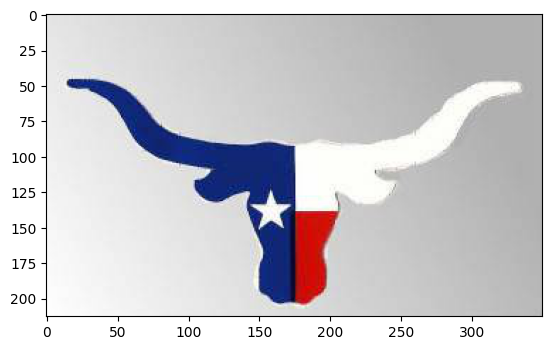

In [3]:
###############################################################################
# Parts a and b
# Read the image from the pickle file
pkl_file = open('ImageSegmentation.pkl', 'rb')
img = pickle.load(pkl_file)
pkl_file.close()

# Find the dimensions of the image
height, width, channels = img.shape

# Report the dimensions
print("Height:", height)
print("Width:", width)
print("Number of Channels:", channels)

# Create and report the image
plt.imshow(img)
plt.show()
###############################################################################

In [4]:
# Setup for part c and beyond
I = img.shape[0]
J = img.shape[1]
numPixels = I * J
redPixelVals = img[:,:,0].flatten()
greenPixelVals = img[:,:,1].flatten()
bluePixelVals = img[:,:,2].flatten()

In [5]:
###############################################################################
# Part c

#Create Queens Neighbor Matrix
#CSR Sparse Initialization
neighborMat = csr_matrix((numPixels,numPixels))

#By Definition, the neighbors of a pixel are the following pixels
adjToNeighbor = np.array([1,J-1,J,J+1,-1,-(J-1),-J,-(J+1)])
neighborGrid = np.array([x + adjToNeighbor for x in range(numPixels)])

#Now we need to adjust the matrix to remove issues at the boundaries
rowNums = np.asarray(np.repeat(list(range(numPixels)),8)).reshape([numPixels,8])
neighborGrid[neighborGrid < 0] = rowNums[neighborGrid < 0]
neighborGrid[neighborGrid > numPixels-1] = rowNums[neighborGrid > numPixels-1]
neighborGrid[J * np.array(range(I)),1] = J * np.array(range(I))
neighborGrid[J * np.array(range(I)),4] = J * np.array(range(I))
neighborGrid[J * np.array(range(I)),7] = J * np.array(range(I))
neighborGrid[J * np.array(range(1,I+1))-1,5] = J * np.array(range(1,I+1))-1
neighborGrid[J * np.array(range(1,I+1))-1,3] = J * np.array(range(1,I+1))-1
neighborGrid[J * np.array(range(1,I+1))-1,0] = J * np.array(range(1,I+1))-1

#Is there a more direct way of doing all this? Probably. But this all works
neighborMat[np.repeat(list(range(numPixels)),8),neighborGrid.flatten()] = 1
neighborMat[np.array(range(numPixels)),np.array(range(numPixels))] = 0

# Find neighbors of pixel 73850
pixel_73850_neighbors = np.where(neighborMat[73850].toarray().flatten() == 1)[0]
print("Neighbors of pixel 73850:", pixel_73850_neighbors)

Neighbors of pixel 73850: [73500 73501 73851 74200 74201]


In [6]:
#Part d

#Now lets find which spots we need to calculate things for the W matrix
ixW = sp.find(neighborMat == 1)

#Initialzie W matrix and set sigma parameter
s = 30
W = csr_matrix((numPixels,numPixels))

# Calculate the W Matrix
rgb_values = np.stack((redPixelVals, greenPixelVals, bluePixelVals)).T
diff = rgb_values[ixW[0], :] - rgb_values[ixW[1], :]
W[ixW[0], ixW[1]] = np.exp(-np.sum(np.square(diff), axis=1) / (2 * s**2))

# Set Wij to 0 for non-neighboring pixels
W = W.multiply(neighborMat)

#Calculate the D Matrix
D = np.squeeze(np.asarray(np.sum(W,axis = 1)))

#Check the values of the D matrix
print("Minimum diagonal value: ", round(D.min(),6))
print("Maximum Value of D: ", D.max())

#Report values of D matrix
# Find the specified diagonal values of D
D_0_0 = D[0]
D_612_612 = D[612]
D_72630_72630 = D[72630]

# Report the values of D matrix
print("D[0, 0]: {:.3f}".format(D_0_0))
print("D[612, 612]: {:.3f}".format(D_612_612))
print("D[72630, 72630]: {:.3f}".format(D_72630_72630))

Minimum diagonal value:  0.000158
Maximum Value of D:  8.0
D[0, 0]: 3.000
D[612, 612]: 7.998
D[72630, 72630]: 5.450


In [7]:
#Part e
#Create the L matrix and LSM matrix

# Compute the Laplacian matrix L
L = diags(D) - W

# Compute the Shi-Malik Normalized Spectral Clustering Laplacian matrix LSM
LSM = diags(1 / D) @ L

# Count the number of nonzero values in the LSM matrix
num_nonzero = LSM.nnz

# Find the specified values of LSM
LSM_55_62 = LSM[55, 62]
LSM_34331_34332 = LSM[34331, 34332]
LSM_74199_74548 = LSM[74199, 74548]

#Part e answers
print("Number of nonzero values in LSM matrix:", num_nonzero)
print("LSM[55, 62]: {:.3f}".format(LSM_55_62))
print("LSM[34331, 34332]: {:.3f}".format(LSM_34331_34332))
print("LSM[74199, 74548]: {:.3f}".format(LSM_74199_74548))

Number of nonzero values in LSM matrix: 667576
LSM[55, 62]: 0.000
LSM[34331, 34332]: -0.124
LSM[74199, 74548]: -0.192


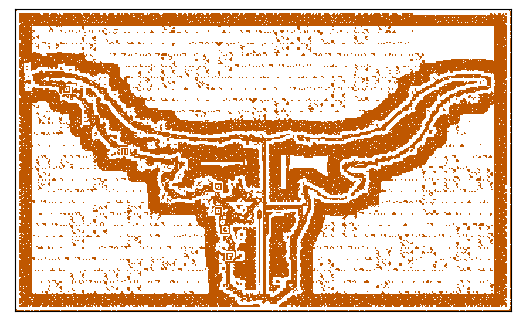

In [8]:
#Part f
#Find the eigenvectors (and values) of the L matrix
K = 10
M = csr_matrix(diags(D))
Minv = csr_matrix(diags(1/D))
initVec = (D > 6)
initVec = initVec / sum(initVec)
lam, v = sp.linalg.eigs(LSM,K,M = M,Minv = Minv,v0 = initVec)

#Pull out the top K vectors to use
Y = np.real(v[:, (np.argsort(np.abs(lam))[::-1])[:K]])

#Normalize the rows of Y
Y = np.transpose(np.transpose(Y)/np.linalg.norm(Y,axis = 1))
Y = np.nan_to_num(Y)

#Perform K-Means on Y
kmeans = KMeans(init = 'k-means++',n_clusters = 2,n_init = 10, max_iter = 300,random_state = 0)
kmeans.fit(Y)

#Create a plot
from matplotlib.colors import from_levels_and_colors
cmap , norm = from_levels_and_colors([-.5,0.5,1.5], ['#FFFFFF','#BF5700'])

clusterImg = np.reshape(kmeans.labels_, (I, J))

plt.imshow(clusterImg,cmap=cmap)
ax = plt.gca()
ax.axes.xaxis.set_visible(False)
ax.axes.yaxis.set_visible(False)
plt.show()